In [1]:
import sys, os
import re
import numpy as np
import synergia
import matplotlib.pyplot as plt
import h5py

Kokkos::OpenMP::initialize WARNING: OMP_PROC_BIND environment variable not set
  In general, for best performance with OpenMP 4.0 or better set OMP_PROC_BIND=spread and OMP_PLACES=threads
  For best performance with OpenMP 3.1 set OMP_PROC_BIND=true
  For unit testing set OMP_PROC_BIND=false



In [2]:
lattice_txt = """
f1 = 15.0;
f2 = 14.0;
fu: multipole, knl={0, 1/f1};
fd: multipole, knl={0, 1/f1};
du: multipole, knl={0, -1/f2};
dd: multipole, knl={0, -1/f2};

r: rfcavity, l=0.0, volt=%volt, harmon=5;

mp: multipole, knl={0.0, 0.0, %sxn, %ocn}, ksl={0.0, %qks, %sxs, %ocs};

bcell: sequence, l=20.0;
r, at=0.0;
fd, at=2.0;
du, at=6.0;
mp, at = 10.0;
dd, at=14.0;
fu, at=18.0;
endsequence;

beam, particle=proton, energy=pmass+0.8;
"""

In [3]:
def get_lattice(volt=0.2, qks=0.0, sxn=0.0, sxs=0.0, ocn=0.0, ocs=0.0):
    latstring = lattice_txt
    latstring = re.sub('%volt', repr(volt), latstring)
    latstring = re.sub('%qks', repr(qks), latstring)
    latstring = re.sub('%sxn', repr(sxn), latstring)
    latstring = re.sub('%sxs', repr(sxs), latstring)
    latstring = re.sub('%ocn', repr(ocn), latstring)
    latstring = re.sub('%ocs', repr(ocs), latstring)

    reader = synergia.lattice.MadX_reader()
    reader.parse(latstring)
    
    lattice = reader.get_lattice('bcell')
    synergia.simulation.Lattice_simulator.tune_circular_lattice(lattice)
    return lattice

In [4]:
def lattice_info(lattice):

    print('lattice length = ', lattice.get_length())
    print(lattice)
    
    refpart = lattice.get_reference_particle()
    energy = refpart.get_total_energy()
    momentum = refpart.get_momentum()
    gamma = refpart.get_gamma()
    beta = refpart.get_beta()

    print('energy: ', energy)
    print('momentum: ', momentum)
    print('gamma: ', gamma)
    print('beta: ', beta)
    
    xtune, ytune, cdt = synergia.simulation.Lattice_simulator.calculate_tune_and_cdt(lattice)
    print('xtune: ', xtune, 'ytune: ', ytune, 'cdT: ', cdt)

    chrom = synergia.simulation.Lattice_simulator.get_chromaticities(lattice)
    print('h chromaticity: ', chrom.horizontal_chromaticity, 'v chromaticity: ', chrom.vertical_chromaticity)
    print('momentum compaction: ', chrom.momentum_compaction)
    print('slip factor: ', chrom.slip_factor)
    print('bucket length: ', synergia.simulation.Lattice_simulator.get_bucket_length(lattice))
    
    one_turn_map = synergia.simulation.Lattice_simulator.get_linear_one_turn_map(lattice)
    
    # print('one turn map')
    # print(one_turn_map)
    v, l = np.linalg.eig(one_turn_map)
    for z in v:
        print('eigenvalue: ', z, 'tune: ', np.log(z).imag/(2*np.pi))

        synergia.simulation.Lattice_simulator.CourantSnyderLatticeFunctions(lattice)
    synergia.simulation.Lattice_simulator.calc_dispersions(lattice)

    elem = lattice.get_elements()[0]
    beta_x = elem.lf.beta.hor
    alpha_x = elem.lf.alpha.hor
    beta_y = elem.lf.beta.ver
    alpha_y = elem.lf.alpha.ver

    print('beta_x: ', beta_x, 'alpha_x: ', alpha_x)
    print('beta_y: ', beta_y, 'alpha_y: ', alpha_y)


In [5]:
lattice_info(get_lattice())

lattice length =  20.0
bcell:
 rfcavity r: freq=63.09212571886666154, harmon=5, l=0, lag=0, shunt=0, volt=0.2000000000000000111
 drift auto_drift_bcell_0: l=2
 multipole fd: tilt=0, knl={0, 0.06666666666666666574}
 drift auto_drift_bcell_1: l=4
 multipole du: tilt=0, knl={0, -0.07142857142857142461}
 drift auto_drift_bcell_2: l=4
 multipole mp: tilt=0, knl={0, 0, 0, 0}, ksl={0, 0, 0, 0}
 drift auto_drift_bcell_3: l=4
 multipole dd: tilt=0, knl={0, -0.07142857142857142461}
 drift auto_drift_bcell_4: l=4
 multipole fu: tilt=0, knl={0, 0.06666666666666666574}
 drift auto_drift_bcell_5: l=2

energy:  1.738272046
momentum:  1.4632960307470255
gamma:  1.8526311781434017
beta:  0.8418107131816728
xtune:  0.12656133142936488 ytune:  0.15503436850803554 cdT:  23.75831013650187
h chromaticity:  -0.15814496914789974 v chromaticity:  -0.14299667930641374
momentum compaction:  -5.548228543261757e-12
slip factor:  -0.2913547231781116
bucket length:  4.0
eigenvalue:  (0.7001360544217688+0.71400945742

In [6]:
volt = 0.2 # RF voltage [GV]
qks = 0.01 # skew quadrupole
sxn = 0.0 # normal sextupole
sxs =  0.0 # skew sextupole
ocn = 0.0 # normal octupole
ocs = 0.0 # skew octupole

In [7]:
lattice_info(get_lattice(volt, qks, sxn, sxs, ocn, ocs))
    
    

lattice length =  20.0
bcell:
 rfcavity r: freq=63.09212571886666154, harmon=5, l=0, lag=0, shunt=0, volt=0.2000000000000000111
 drift auto_drift_bcell_0: l=2
 multipole fd: tilt=0, knl={0, 0.06666666666666666574}
 drift auto_drift_bcell_1: l=4
 multipole du: tilt=0, knl={0, -0.07142857142857142461}
 drift auto_drift_bcell_2: l=4
 multipole mp: tilt=0, knl={0, 0, 0, 0}, ksl={0, 0.01000000000000000021, 0, 0}
 drift auto_drift_bcell_3: l=4
 multipole dd: tilt=0, knl={0, -0.07142857142857142461}
 drift auto_drift_bcell_4: l=4
 multipole fu: tilt=0, knl={0, 0.06666666666666666574}
 drift auto_drift_bcell_5: l=2

energy:  1.738272046
momentum:  1.4632960307470255
gamma:  1.8526311781434017
beta:  0.8418107131816728
xtune:  0.11682254356469797 ytune:  0.16304948623888382 cdT:  23.75831013650187
h chromaticity:  -0.15852587345911714 v chromaticity:  -0.14631154056666631
momentum compaction:  -5.548228543261757e-12
slip factor:  -0.2913547231781116
bucket length:  4.0
eigenvalue:  (0.742489120

In [8]:
def create_propagator(lattice):
    stepper = synergia.simulation.Independent_stepper_elements(1)
    propagator = synergia.simulation.Propagator(lattice, stepper)
    return propagator

In [9]:
def create_sim(lattice):
    # need the lattice for the reference particle
    refpart = lattice.get_reference_particle()
    # 51 test particles in X
    # 50 test particles in Y
    # 50 test particles in s
    NX = 51
    NY = 50
    NS = 50
    num_particles = NX + NY + NS
    real_particles = 0.5e9
    sim = synergia.simulation.Bunch_simulator.create_single_bunch_simulator(
        refpart, num_particles, real_particles)
    
    # populate the bunch with particles aout to  5 transverse sigma and full bucket
    
    synergia.simulation.Lattice_simulator.CourantSnyderLatticeFunctions(lattice)
    synergia.simulation.Lattice_simulator.calc_dispersions(lattice)
    
    elem = lattice.get_elements()[0]
    beta_x = elem.lf.beta.hor
    alpha_x = elem.lf.alpha.hor
    beta_y = elem.lf.beta.ver
    alpha_y = elem.lf.alpha.ver
    
    betagamma = refpart.get_beta() * refpart.get_gamma()
    emitx = 20.0e-6/betagamma
    emity = 20.0e-6/betagamma
    sigx = np.sqrt(emitx * beta_x)
    sigy = np.sqrt(emity * beta_y)
    bucketlength = synergia.simulation.Lattice_simulator.get_bucket_length(lattice)
    
    bunch = sim.get_bunch(0, 0)
    bunch.checkout_particles()
    localpart = bunch.get_particles_numpy()
    dx = sigx/10.0
    dy = sigy/10.0
    ds = bucketlength/(2*50.0*refpart.get_beta())
    localpart[:, 0:6] = 0.0
    localpart[0:NX, 0] = dx * np.arange(0, NX)
    localpart[NX:NX+NY, 2] = dy * np.arange(1, NY+1)
    localpart[NX+NY:NX+NY+NS, 4] = ds * np.arange(0, NS)
    bunch.checkin_particles()
    
    return sim


In [10]:
def register_diagnostics(sim):
    npart = sim.get_bunch(0, 0).get_total_num()

    diag = synergia.bunch.Diagnostics_bulk_track('tracks.h5', npart, 0)
    sim.reg_diag_per_turn(diag)
    return


In [11]:
def run(volt=0.2, qks=0.0, sxn=0.0, sxs=0.0, ocn=0.0, ocs=0.0):
    
    print('Running with options')
    print(f'\tvolt: {volt} (RF voltage [MV])')
    print(f'\tqks: {qks} (skew quadrupole)')
    print(f'\tsxn: {sxn} (normal sextupole)')
    print(f'\tsxs: {sxs} (skew sextupole)')
    print(f'\tocn: {ocn} (normal octupole)')
    print(f'\tocs: {ocs} (skew octupole)')

    lattice = get_lattice(volt, qks, sxn, sxs, ocn, ocs)
    
    sim = create_sim(lattice)

    # normal form
    nf = synergia.simulation.Lattice_simulator.calculate_normal_form_o5(lattice)

    register_diagnostics(sim)

    fh = open("nf.dat", "w")

    def action(sim, lattice, turn):
        bunch = sim.get_bunch()
        bunch.checkout_particles()
        hparts = bunch.get_particles_numpy()

        for p in range(bunch.size()):
            hp = np.zeros(6, dtype='d')
            hp[:] = hparts[p, 0:6]
            tm = nf.convert_xyz_to_normal(hp)

            print('{0} {1} {2} {3} {4} {5} '.format(
                tm[0].real, tm[0].imag,
                tm[1].real, tm[1].imag,
                tm[2].real, tm[2].imag), file=fh, end="")

        print(file=fh)
        fh.flush()

    # register turn end action for writing particles out
    sim.reg_prop_action_turn_end(action)

    propagator = create_propagator(lattice)
    simlog = synergia.utils.parallel_utils.Logger(0, 
            synergia.utils.parallel_utils.LoggerV.INFO_TURN)

    propagator.propagate(sim, simlog, 1000)

    print('run finished')

In [12]:
def plot_traj(track_file, nf_file):
    h5 = h5py.File(track_file, 'r')
    tracks = h5.get('track_coords')
    # get mass and pz to convert cdT to z
    mass = h5.get('mass')[()]
    pz = h5.get('pz')[()]
    betagamma = pz/mass
    gamma = np.sqrt(betagamma**2 + 1)
    beta = betagamma/gamma

    nfdata = np.loadtxt(nf_file)
    nturn = nfdata.shape[0]
    npart = nfdata.shape[1]//6
    nftracks = np.zeros((nturn, npart, 6))
    for i in range(nturn):
        nftracks[i, :, :] = nfdata[i, :].reshape(npart, 6)
    del nfdata

    plt.figure()
    plt.title('x vs xp')
    for part in range(1, 51, 10):
        plt.plot(tracks[:, part, 0], tracks[:, part, 1], '.', label=f'particle {part}')
    plt.xlabel('x [m]')
    plt.ylabel('xp')
    plt.legend(loc='best')

    plt.figure()
    plt.title('real X vs. imag X')
    for part in range(1,51, 10):
        plt.plot(nftracks[:, part, 0], nftracks[:, part, 1], '.', label=f'particle {part}')
    plt.xlabel('real X')
    plt.ylabel('imag X')
    plt.legend(loc='best')
    
    plt.figure()
    plt.title('y vs. yp')
    for part in range(51, 101, 10):
        plt.plot(tracks[:, part, 2], tracks[:, part, 3], '.', label=f'particle {part}')
    plt.xlabel('y [m]')
    plt.ylabel('yp')
    plt.legend(loc='best')

    plt.figure()
    plt.title('real Y vs. imag Y')
    for part in range(51,101, 10):
        plt.plot(nftracks[:, part, 2], nftracks[:, part, 3], '.', label=f'particle {part}')
    plt.xlabel('real Y')
    plt.ylabel('imag Y')
    plt.legend(loc='best')

    plt.figure()
    plt.title('z vs. dp/p')
    for part in list(range(101, 151, 10)) + [150]:
        plt.plot(-tracks[:, part, 4]*beta, tracks[:, part, 5], '.', label=f'particle {part}')
    plt.xlabel('z [m]')
    plt.ylabel('dp/p')
    plt.legend(loc='best')

    plt.figure()
    plt.title('real S vs. imag S')
    for part in list(range(101, 151, 10))+[150]:
        plt.plot(nftracks[:, part, 4], nftracks[:, part, 5], '.', label=f'particle {part}')
    plt.xlabel('real S')
    plt.ylabel('imag S')
    plt.legend(loc='best')

    h5.close()

In [13]:
run(qks=0.001)

Running with options
	volt: 0.2 (RF voltage [MV])
	qks: 0.001 (skew quadrupole)
	sxn: 0.0 (normal sextupole)
	sxs: 0.0 (skew sextupole)
	ocn: 0.0 (normal octupole)
	ocs: 0.0 (skew octupole)
WARNING -- filterTransverseTunes: "Horizontal" matrix does not pass symplecticity test. JH( 0, 0 ) = 8.88178e-16, JH( 1, 1 ) = 1.11022e-15. The ratio is 9
WARNING -- filterTransverseTunes: "Vertical" matrix does not pass symplecticity test. JV( 0, 0 ) = 9.99201e-16, JV( 1, 1 ) = 8.88178e-16. The ratio is 17
WARNING -- filterTransverseTunes: "Horizontal" matrix does not pass symplecticity test. JH( 0, 0 ) = 8.88178e-16, JH( 1, 1 ) = 1.11022e-15. The ratio is 9
WARNING -- filterTransverseTunes: "Vertical" matrix does not pass symplecticity test. JV( 0, 0 ) = 9.99201e-16, JV( 1, 1 ) = 8.88178e-16. The ratio is 17
WARNING -- filterTransverseTunes: "Horizontal" matrix does not pass symplecticity test. JH( 0, 0 ) = 5.55112e-16, JH( 1, 1 ) = 2.22045e-16. The ratio is 2.33333
WARNING -- filterTransverseTune

Propagator: turn 92/inf., time = 0.062s, macroparticles = (151) / ()
Propagator: turn 93/inf., time = 0.002s, macroparticles = (151) / ()
Propagator: turn 94/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 95/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 96/inf., time = 0.003s, macroparticles = (151) / ()
Propagator: turn 97/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 98/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 99/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 100/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 101/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 102/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 103/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 104/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 105/inf., time = 0.002s, macroparticles = (151) / ()
Propagator: turn 106/inf., t

Propagator: turn 209/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 210/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 211/inf., time = 0.002s, macroparticles = (151) / ()
Propagator: turn 212/inf., time = 0.010s, macroparticles = (151) / ()
Propagator: turn 213/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 214/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 215/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 216/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 217/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 218/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 219/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 220/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 221/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 222/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 223

Propagator: turn 326/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 327/inf., time = 0.018s, macroparticles = (151) / ()
Propagator: turn 328/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 329/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 330/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 331/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 332/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 333/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 334/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 335/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 336/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 337/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 338/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 339/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 340

Propagator: turn 443/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 444/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 445/inf., time = 0.049s, macroparticles = (151) / ()
Propagator: turn 446/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 447/inf., time = 0.025s, macroparticles = (151) / ()
Propagator: turn 448/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 449/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 450/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 451/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 452/inf., time = 0.002s, macroparticles = (151) / ()
Propagator: turn 453/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 454/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 455/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 456/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 457

Propagator: turn 560/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 561/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 562/inf., time = 0.002s, macroparticles = (151) / ()
Propagator: turn 563/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 564/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 565/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 566/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 567/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 568/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 569/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 570/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 571/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 572/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 573/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 574

Propagator: turn 677/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 678/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 679/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 680/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 681/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 682/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 683/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 684/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 685/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 686/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 687/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 688/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 689/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 690/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 691

Propagator: turn 794/inf., time = 0.003s, macroparticles = (151) / ()
Propagator: turn 795/inf., time = 0.020s, macroparticles = (151) / ()
Propagator: turn 796/inf., time = 0.111s, macroparticles = (151) / ()
Propagator: turn 797/inf., time = 0.089s, macroparticles = (151) / ()
Propagator: turn 798/inf., time = 0.083s, macroparticles = (151) / ()
Propagator: turn 799/inf., time = 0.113s, macroparticles = (151) / ()
Propagator: turn 800/inf., time = 0.085s, macroparticles = (151) / ()
Propagator: turn 801/inf., time = 0.064s, macroparticles = (151) / ()
Propagator: turn 802/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 803/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 804/inf., time = 0.002s, macroparticles = (151) / ()
Propagator: turn 805/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 806/inf., time = 0.002s, macroparticles = (151) / ()
Propagator: turn 807/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 808

Propagator: turn 911/inf., time = 0.077s, macroparticles = (151) / ()
Propagator: turn 912/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 913/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 914/inf., time = 0.022s, macroparticles = (151) / ()
Propagator: turn 915/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 916/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 917/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 918/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 919/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 920/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 921/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 922/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 923/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 924/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 925

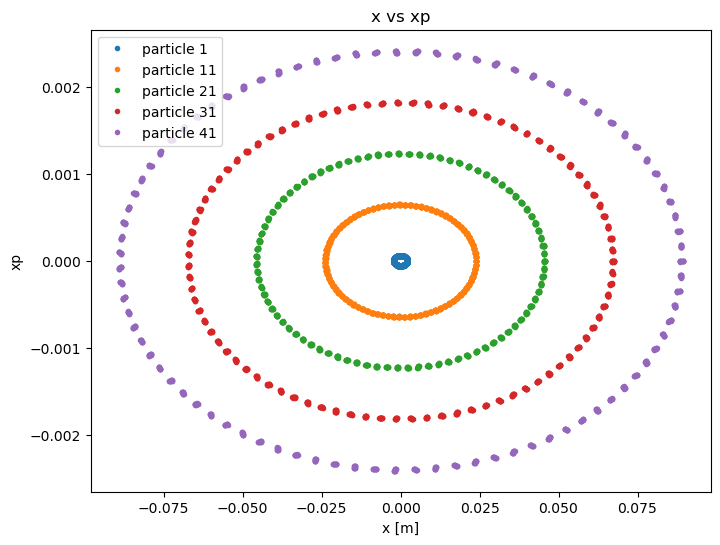

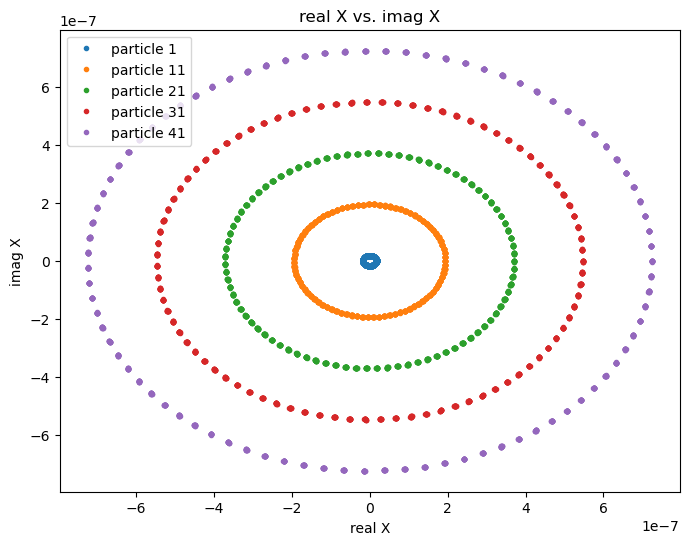

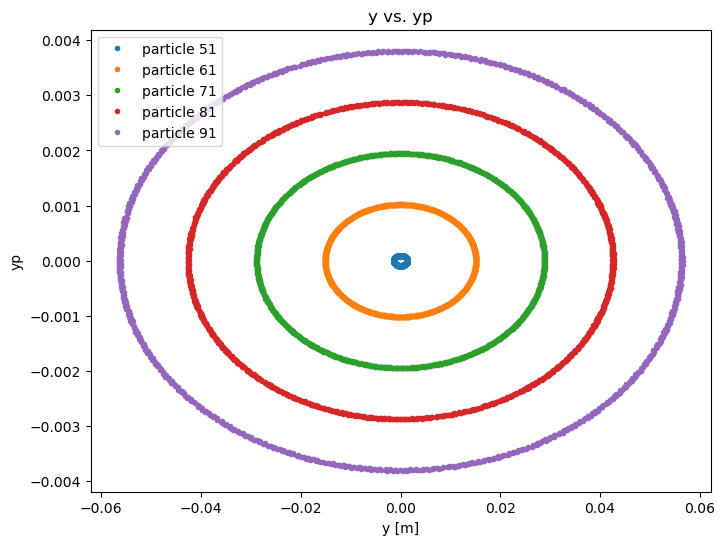

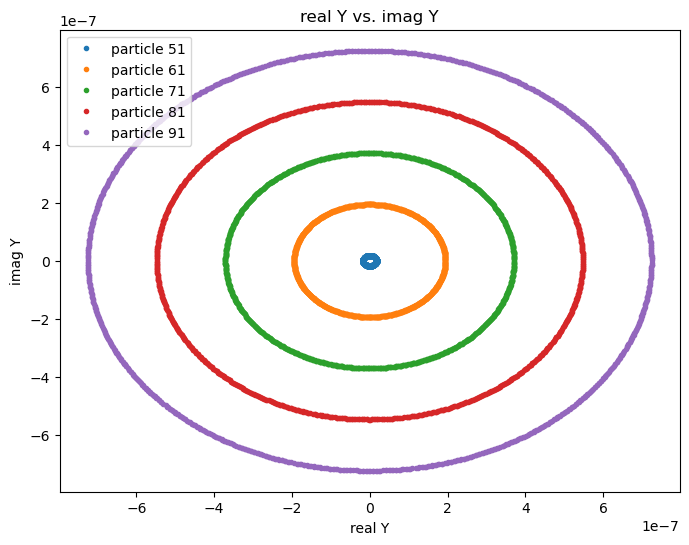

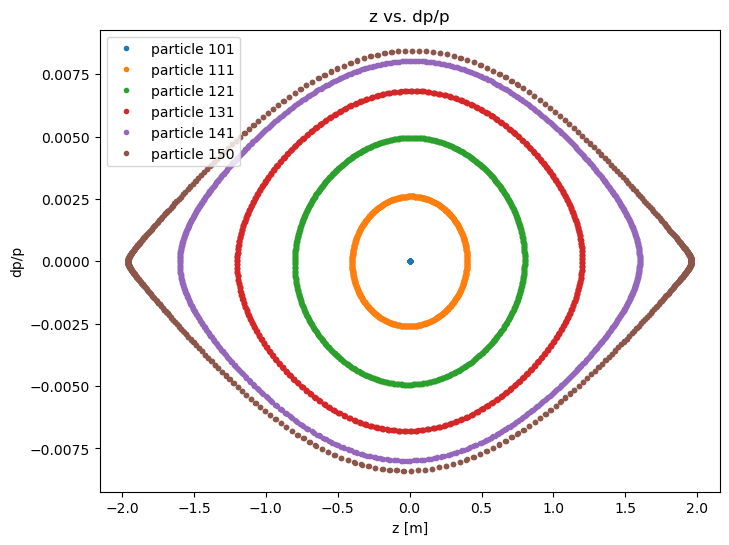

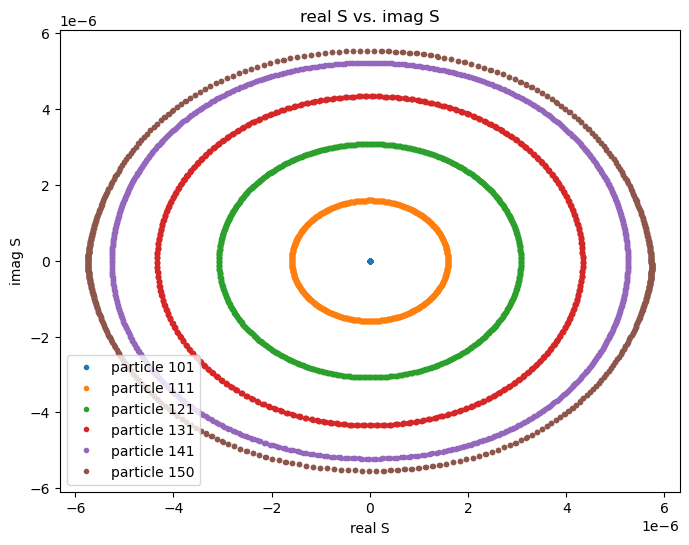

In [14]:
plot_traj('tracks.h5', 'nf.dat')

In [15]:
run(sxn=0.5)

Running with options
	volt: 0.2 (RF voltage [MV])
	qks: 0.0 (skew quadrupole)
	sxn: 0.5 (normal sextupole)
	sxs: 0.0 (skew sextupole)
	ocn: 0.0 (normal octupole)
	ocs: 0.0 (skew octupole)
)
Propagator: turn 970/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 971/inf., time = 0.042s, macroparticles = (151) / ()
Propagator: turn 972/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 973/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 974/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 975/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 976/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 977/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 978/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 979/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 980/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 981/inf., time = 0.000s

Propagator: turn 86/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 87/inf., time = 0.003s, macroparticles = (151) / ()
Propagator: turn 88/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 89/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 90/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 91/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 92/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 93/inf., time = 0.008s, macroparticles = (151) / ()
Propagator: turn 94/inf., time = 0.057s, macroparticles = (151) / ()
Propagator: turn 95/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 96/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 97/inf., time = 0.003s, macroparticles = (151) / ()
Propagator: turn 98/inf., time = 0.004s, macroparticles = (151) / ()
Propagator: turn 99/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 100/inf., time = 

Propagator: turn 203/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 204/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 205/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 206/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 207/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 208/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 209/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 210/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 211/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 212/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 213/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 214/inf., time = 0.004s, macroparticles = (151) / ()
Propagator: turn 215/inf., time = 0.027s, macroparticles = (151) / ()
Propagator: turn 216/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 217

Propagator: turn 320/inf., time = 0.070s, macroparticles = (151) / ()
Propagator: turn 321/inf., time = 0.102s, macroparticles = (151) / ()
Propagator: turn 322/inf., time = 0.022s, macroparticles = (151) / ()
Propagator: turn 323/inf., time = 0.065s, macroparticles = (151) / ()
Propagator: turn 324/inf., time = 0.075s, macroparticles = (151) / ()
Propagator: turn 325/inf., time = 0.046s, macroparticles = (151) / ()
Propagator: turn 326/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 327/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 328/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 329/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 330/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 331/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 332/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 333/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 334

Propagator: turn 437/inf., time = 0.030s, macroparticles = (151) / ()
Propagator: turn 438/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 439/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 440/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 441/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 442/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 443/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 444/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 445/inf., time = 0.002s, macroparticles = (151) / ()
Propagator: turn 446/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 447/inf., time = 0.003s, macroparticles = (151) / ()
Propagator: turn 448/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 449/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 450/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 451

Propagator: turn 554/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 555/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 556/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 557/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 558/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 559/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 560/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 561/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 562/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 563/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 564/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 565/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 566/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 567/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 568

Propagator: turn 671/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 672/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 673/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 674/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 675/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 676/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 677/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 678/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 679/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 680/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 681/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 682/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 683/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 684/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 685

Propagator: turn 788/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 789/inf., time = 0.005s, macroparticles = (151) / ()
Propagator: turn 790/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 791/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 792/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 793/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 794/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 795/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 796/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 797/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 798/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 799/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 800/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 801/inf., time = 0.026s, macroparticles = (151) / ()
Propagator: turn 802

Propagator: turn 905/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 906/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 907/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 908/inf., time = 0.005s, macroparticles = (151) / ()
Propagator: turn 909/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 910/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 911/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 912/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 913/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 914/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 915/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 916/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 917/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 918/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 919

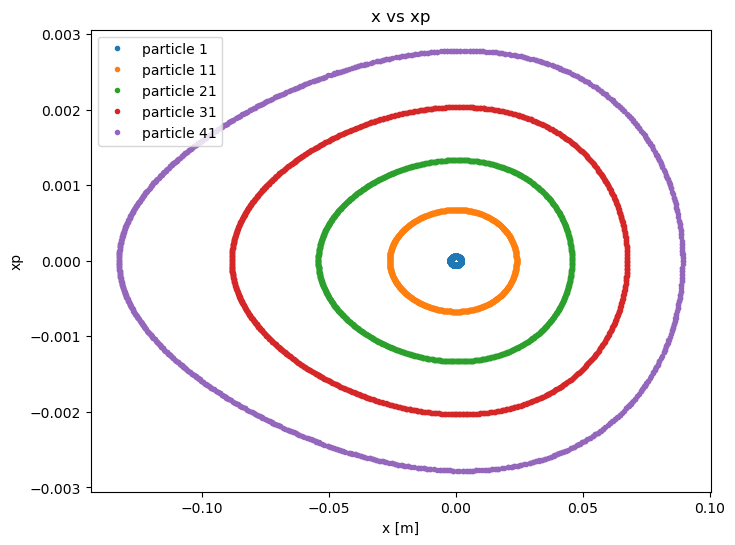

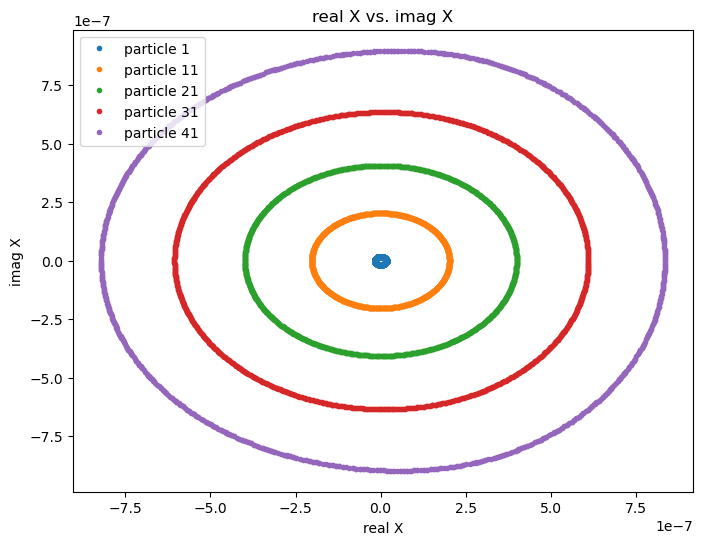

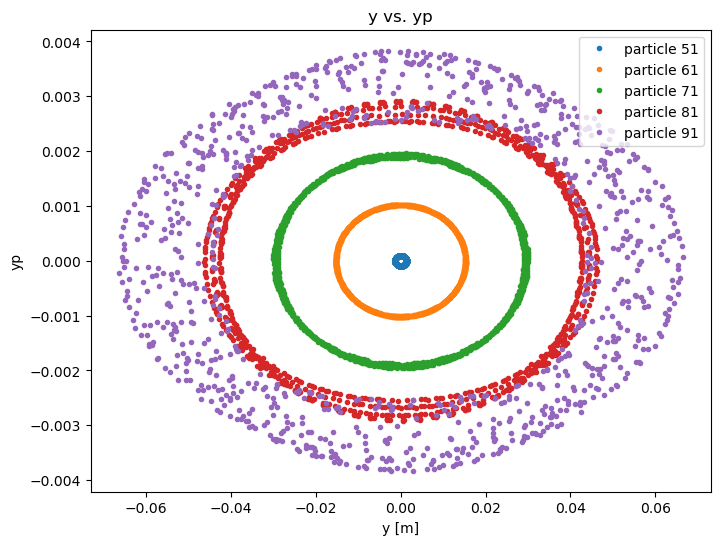

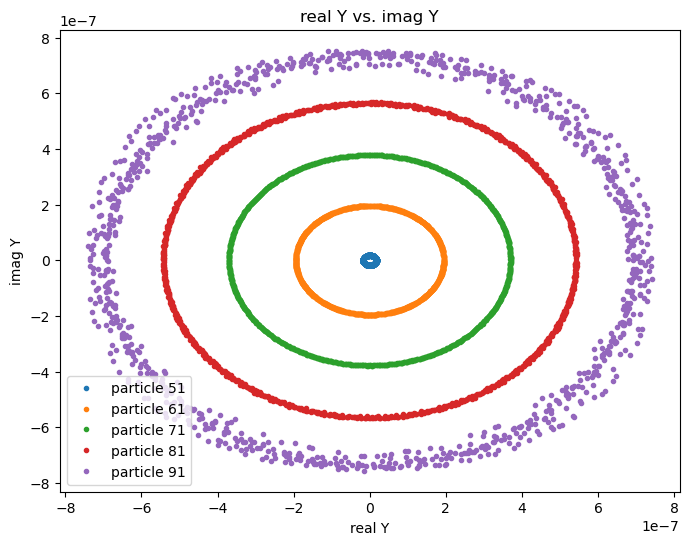

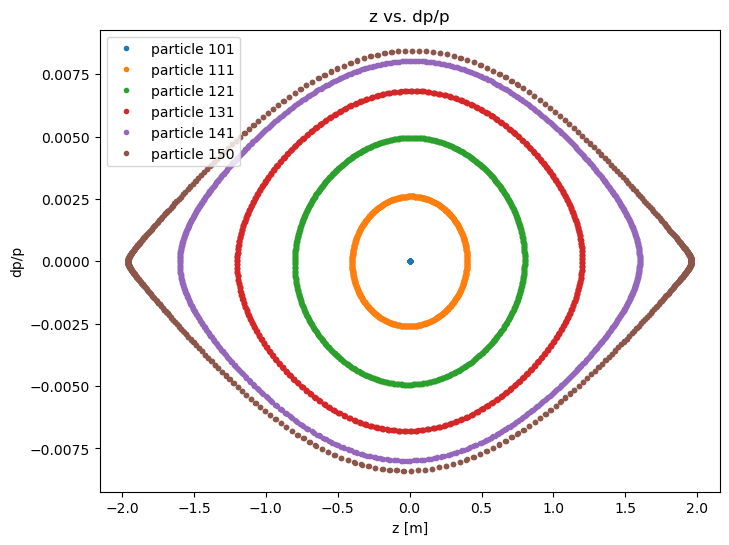

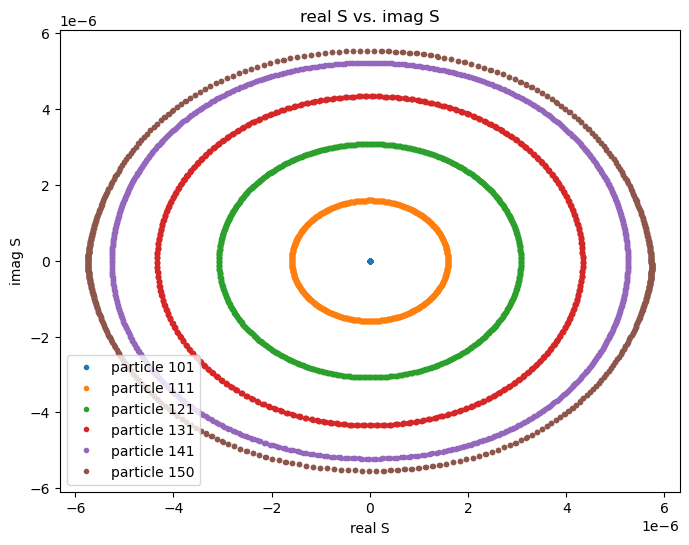

In [16]:
plot_traj('tracks.h5', 'nf.dat')

In [17]:
run(sxn=0.6)

Running with options
	volt: 0.2 (RF voltage [MV])
	qks: 0.0 (skew quadrupole)
	sxn: 0.6 (normal sextupole)
	sxs: 0.0 (skew sextupole)
	ocn: 0.0 (normal octupole)
	ocs: 0.0 (skew octupole)
0.000s, macroparticles = (151) / ()
Propagator: turn 965/inf., time = 0.005s, macroparticles = (151) / ()
Propagator: turn 966/inf., time = 0.001s, macroparticles = (151) / ()
Propagator: turn 967/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 968/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 969/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 970/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 971/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 972/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 973/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 974/inf., time = 0.000s, macroparticles = (151) / ()
Propagator: turn 975/inf., time = 0.000s, macroparticles = (151) / ()
Propag

Propagator: turn 81/inf., time = 0.000s, macroparticles = (141) / ()
Propagator: turn 82/inf., time = 0.000s, macroparticles = (141) / ()
Propagator: turn 83/inf., time = 0.087s, macroparticles = (141) / ()
Propagator: turn 84/inf., time = 0.134s, macroparticles = (141) / ()
Propagator: turn 85/inf., time = 0.040s, macroparticles = (141) / ()
Propagator: turn 86/inf., time = 0.085s, macroparticles = (141) / ()
Propagator: turn 87/inf., time = 0.089s, macroparticles = (141) / ()
Propagator: turn 88/inf., time = 0.003s, macroparticles = (141) / ()
Propagator: turn 89/inf., time = 0.001s, macroparticles = (141) / ()
Propagator: turn 90/inf., time = 0.019s, macroparticles = (141) / ()
Propagator: turn 91/inf., time = 0.026s, macroparticles = (141) / ()
Propagator: turn 92/inf., time = 0.101s, macroparticles = (141) / ()
Propagator: turn 93/inf., time = 0.000s, macroparticles = (141) / ()
Propagator: turn 94/inf., time = 0.000s, macroparticles = (141) / ()
Propagator: turn 95/inf., time = 0

Propagator: turn 198/inf., time = 0.000s, macroparticles = (140) / ()
Propagator: turn 199/inf., time = 0.000s, macroparticles = (140) / ()
Propagator: turn 200/inf., time = 0.082s, macroparticles = (140) / ()
Propagator: turn 201/inf., time = 0.004s, macroparticles = (140) / ()
Propagator: turn 202/inf., time = 0.021s, macroparticles = (140) / ()
Propagator: turn 203/inf., time = 0.004s, macroparticles = (140) / ()
Propagator: turn 204/inf., time = 0.000s, macroparticles = (140) / ()
Propagator: turn 205/inf., time = 0.043s, macroparticles = (140) / ()
Propagator: turn 206/inf., time = 0.000s, macroparticles = (140) / ()
Propagator: turn 207/inf., time = 0.070s, macroparticles = (140) / ()
Propagator: turn 208/inf., time = 0.042s, macroparticles = (139) / ()
Propagator: turn 209/inf., time = 0.082s, macroparticles = (139) / ()
Propagator: turn 210/inf., time = 0.061s, macroparticles = (139) / ()
Propagator: turn 211/inf., time = 0.000s, macroparticles = (139) / ()
Propagator: turn 212

Propagator: turn 315/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 316/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 317/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 318/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 319/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 320/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 321/inf., time = 0.065s, macroparticles = (138) / ()
Propagator: turn 322/inf., time = 0.004s, macroparticles = (138) / ()
Propagator: turn 323/inf., time = 0.073s, macroparticles = (138) / ()
Propagator: turn 324/inf., time = 0.103s, macroparticles = (138) / ()
Propagator: turn 325/inf., time = 0.022s, macroparticles = (138) / ()
Propagator: turn 326/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 327/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 328/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 329

Propagator: turn 432/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 433/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 434/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 435/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 436/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 437/inf., time = 0.009s, macroparticles = (138) / ()
Propagator: turn 438/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 439/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 440/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 441/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 442/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 443/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 444/inf., time = 0.028s, macroparticles = (138) / ()
Propagator: turn 445/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 446

Propagator: turn 549/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 550/inf., time = 0.011s, macroparticles = (138) / ()
Propagator: turn 551/inf., time = 0.006s, macroparticles = (138) / ()
Propagator: turn 552/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 553/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 554/inf., time = 0.011s, macroparticles = (138) / ()
Propagator: turn 555/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 556/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 557/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 558/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 559/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 560/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 561/inf., time = 0.079s, macroparticles = (138) / ()
Propagator: turn 562/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 563

Propagator: turn 666/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 667/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 668/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 669/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 670/inf., time = 0.004s, macroparticles = (138) / ()
Propagator: turn 671/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 672/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 673/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 674/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 675/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 676/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 677/inf., time = 0.014s, macroparticles = (138) / ()
Propagator: turn 678/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 679/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 680

Propagator: turn 783/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 784/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 785/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 786/inf., time = 0.010s, macroparticles = (138) / ()
Propagator: turn 787/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 788/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 789/inf., time = 0.010s, macroparticles = (138) / ()
Propagator: turn 790/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 791/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 792/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 793/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 794/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 795/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 796/inf., time = 0.088s, macroparticles = (138) / ()
Propagator: turn 797

Propagator: turn 900/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 901/inf., time = 0.062s, macroparticles = (138) / ()
Propagator: turn 902/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 903/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 904/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 905/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 906/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 907/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 908/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 909/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 910/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 911/inf., time = 0.121s, macroparticles = (138) / ()
Propagator: turn 912/inf., time = 0.021s, macroparticles = (138) / ()
Propagator: turn 913/inf., time = 0.087s, macroparticles = (138) / ()
Propagator: turn 914

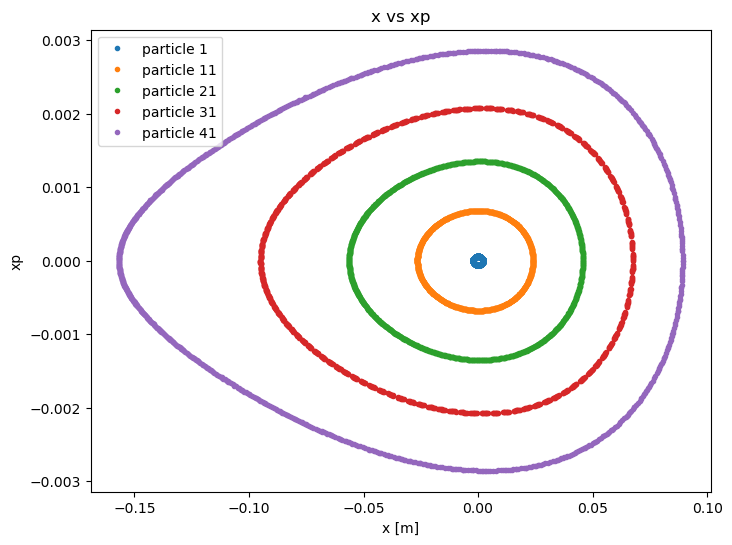

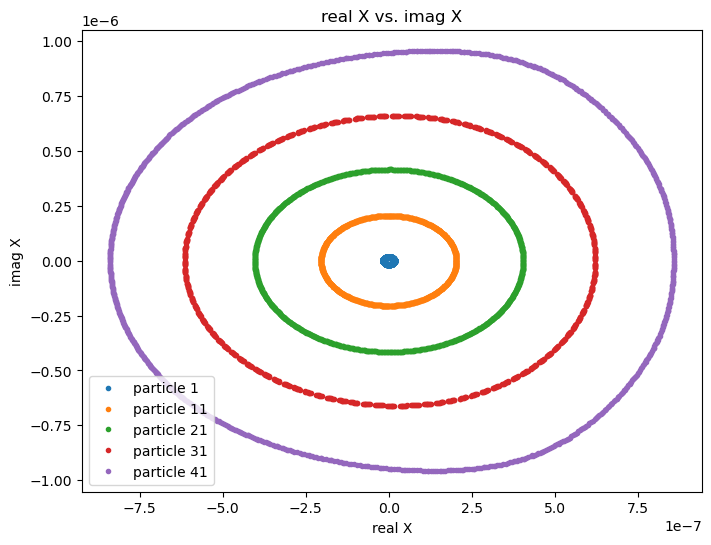

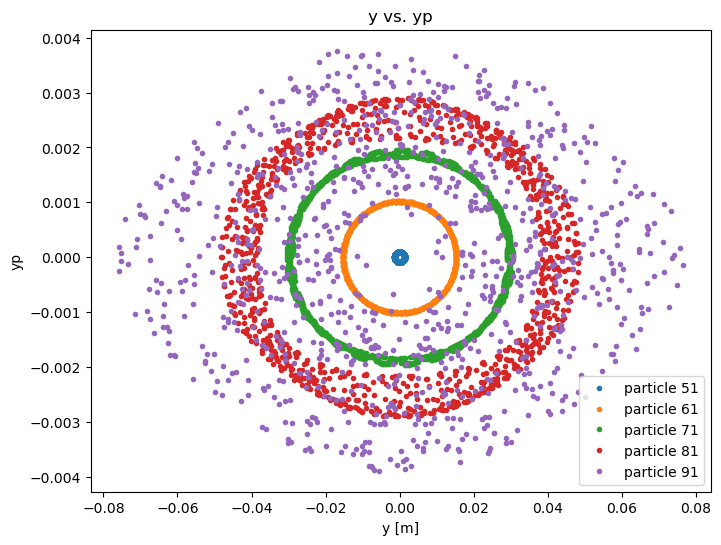

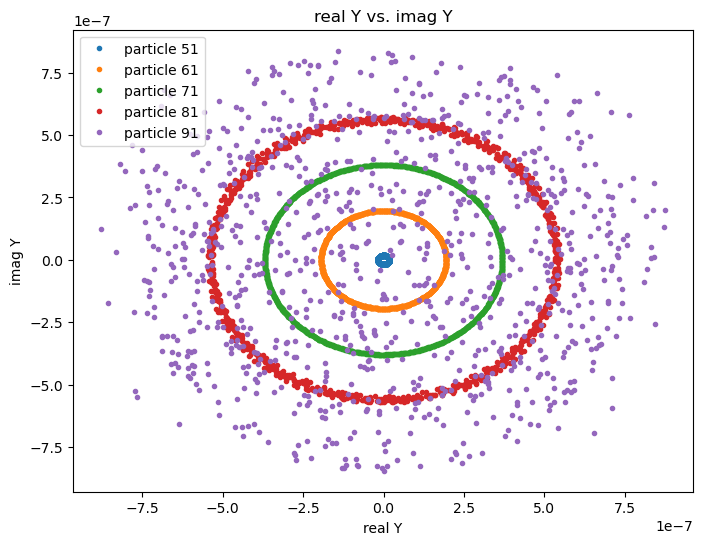

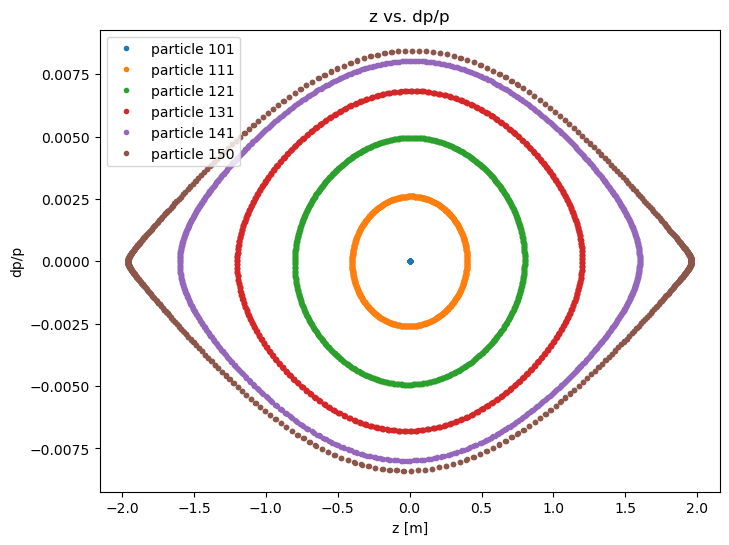

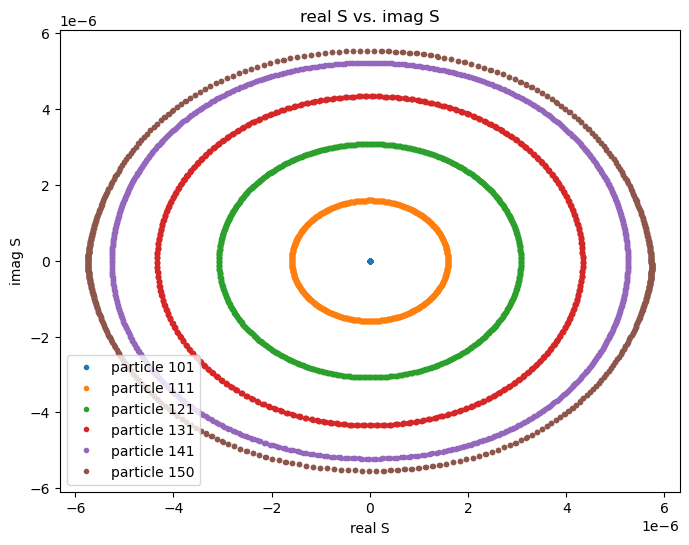

In [18]:
plot_traj('tracks.h5', 'nf.dat')

In [19]:
run(sxs=0.5)

Running with options
	volt: 0.2 (RF voltage [MV])
	qks: 0.0 (skew quadrupole)
	sxn: 0.0 (normal sextupole)
	sxs: 0.5 (skew sextupole)
	ocn: 0.0 (normal octupole)
	ocs: 0.0 (skew octupole)
Propagator: turn 959/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 960/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 961/inf., time = 0.007s, macroparticles = (138) / ()
Propagator: turn 962/inf., time = 0.016s, macroparticles = (138) / ()
Propagator: turn 963/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 964/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 965/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 966/inf., time = 0.001s, macroparticles = (138) / ()
Propagator: turn 967/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 968/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 969/inf., time = 0.000s, macroparticles = (138) / ()
Propagator: turn 970/inf., time = 0.000s, 

Propagator: turn 75/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 76/inf., time = 0.002s, macroparticles = (144) / ()
Propagator: turn 77/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 78/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 79/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 80/inf., time = 0.036s, macroparticles = (144) / ()
Propagator: turn 81/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 82/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 83/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 84/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 85/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 86/inf., time = 0.001s, macroparticles = (144) / ()
Propagator: turn 87/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 88/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 89/inf., time = 0

Propagator: turn 192/inf., time = 0.130s, macroparticles = (144) / ()
Propagator: turn 193/inf., time = 0.001s, macroparticles = (144) / ()
Propagator: turn 194/inf., time = 0.020s, macroparticles = (144) / ()
Propagator: turn 195/inf., time = 0.003s, macroparticles = (144) / ()
Propagator: turn 196/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 197/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 198/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 199/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 200/inf., time = 0.001s, macroparticles = (144) / ()
Propagator: turn 201/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 202/inf., time = 0.048s, macroparticles = (144) / ()
Propagator: turn 203/inf., time = 0.074s, macroparticles = (144) / ()
Propagator: turn 204/inf., time = 0.001s, macroparticles = (144) / ()
Propagator: turn 205/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 206

Propagator: turn 309/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 310/inf., time = 0.012s, macroparticles = (144) / ()
Propagator: turn 311/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 312/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 313/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 314/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 315/inf., time = 0.002s, macroparticles = (144) / ()
Propagator: turn 316/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 317/inf., time = 0.000s, macroparticles = (144) / ()
Propagator: turn 318/inf., time = 0.002s, macroparticles = (143) / ()
Propagator: turn 319/inf., time = 0.040s, macroparticles = (143) / ()
Propagator: turn 320/inf., time = 0.012s, macroparticles = (143) / ()
Propagator: turn 321/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 322/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 323

Propagator: turn 426/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 427/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 428/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 429/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 430/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 431/inf., time = 0.088s, macroparticles = (143) / ()
Propagator: turn 432/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 433/inf., time = 0.108s, macroparticles = (143) / ()
Propagator: turn 434/inf., time = 0.069s, macroparticles = (143) / ()
Propagator: turn 435/inf., time = 0.067s, macroparticles = (143) / ()
Propagator: turn 436/inf., time = 0.077s, macroparticles = (143) / ()
Propagator: turn 437/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 438/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 439/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 440

Propagator: turn 543/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 544/inf., time = 0.011s, macroparticles = (143) / ()
Propagator: turn 545/inf., time = 0.009s, macroparticles = (143) / ()
Propagator: turn 546/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 547/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 548/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 549/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 550/inf., time = 0.071s, macroparticles = (143) / ()
Propagator: turn 551/inf., time = 0.066s, macroparticles = (143) / ()
Propagator: turn 552/inf., time = 0.075s, macroparticles = (143) / ()
Propagator: turn 553/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 554/inf., time = 0.002s, macroparticles = (143) / ()
Propagator: turn 555/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 556/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 557

Propagator: turn 660/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 661/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 662/inf., time = 0.005s, macroparticles = (143) / ()
Propagator: turn 663/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 664/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 665/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 666/inf., time = 0.006s, macroparticles = (143) / ()
Propagator: turn 667/inf., time = 0.003s, macroparticles = (143) / ()
Propagator: turn 668/inf., time = 0.092s, macroparticles = (143) / ()
Propagator: turn 669/inf., time = 0.057s, macroparticles = (143) / ()
Propagator: turn 670/inf., time = 0.002s, macroparticles = (143) / ()
Propagator: turn 671/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 672/inf., time = 0.075s, macroparticles = (143) / ()
Propagator: turn 673/inf., time = 0.021s, macroparticles = (143) / ()
Propagator: turn 674

Propagator: turn 777/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 778/inf., time = 0.060s, macroparticles = (143) / ()
Propagator: turn 779/inf., time = 0.021s, macroparticles = (143) / ()
Propagator: turn 780/inf., time = 0.073s, macroparticles = (143) / ()
Propagator: turn 781/inf., time = 0.073s, macroparticles = (143) / ()
Propagator: turn 782/inf., time = 0.019s, macroparticles = (143) / ()
Propagator: turn 783/inf., time = 0.068s, macroparticles = (143) / ()
Propagator: turn 784/inf., time = 0.087s, macroparticles = (143) / ()
Propagator: turn 785/inf., time = 0.004s, macroparticles = (143) / ()
Propagator: turn 786/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 787/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 788/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 789/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 790/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 791

Propagator: turn 895/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 896/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 897/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 898/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 899/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 900/inf., time = 0.042s, macroparticles = (143) / ()
Propagator: turn 901/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 902/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 903/inf., time = 0.005s, macroparticles = (143) / ()
Propagator: turn 904/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 905/inf., time = 0.010s, macroparticles = (143) / ()
Propagator: turn 906/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 907/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 908/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 909

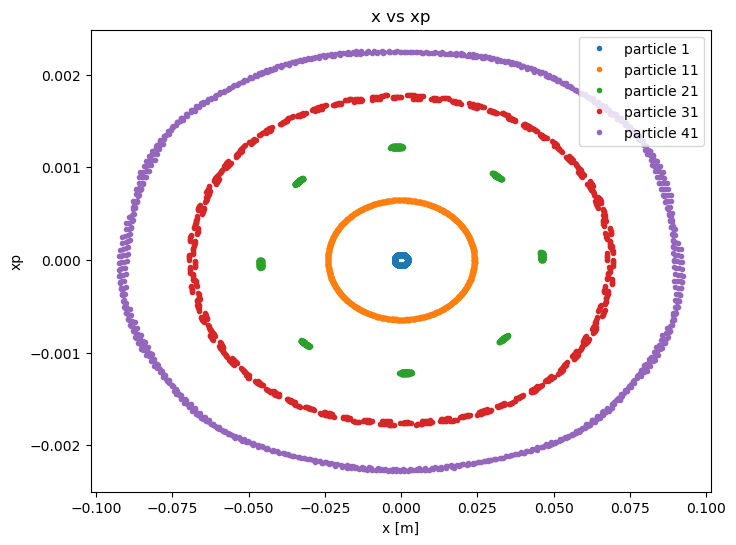

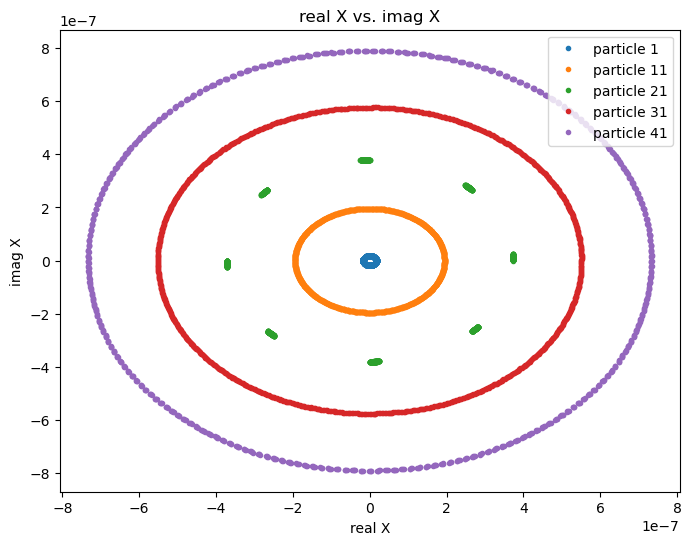

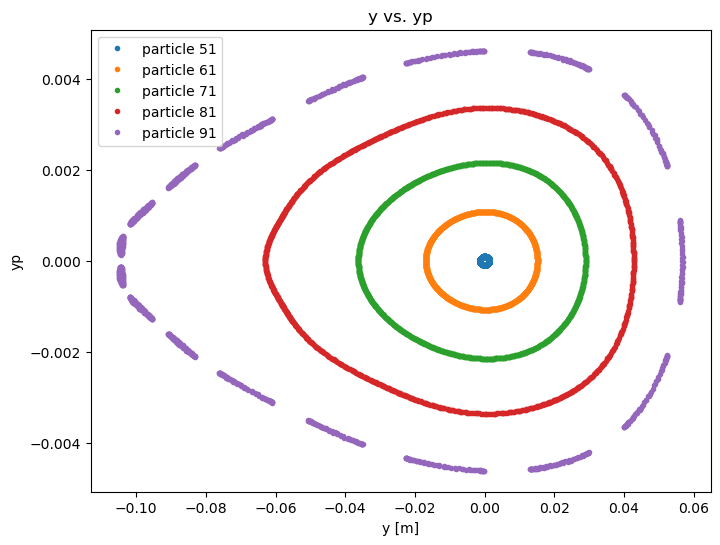

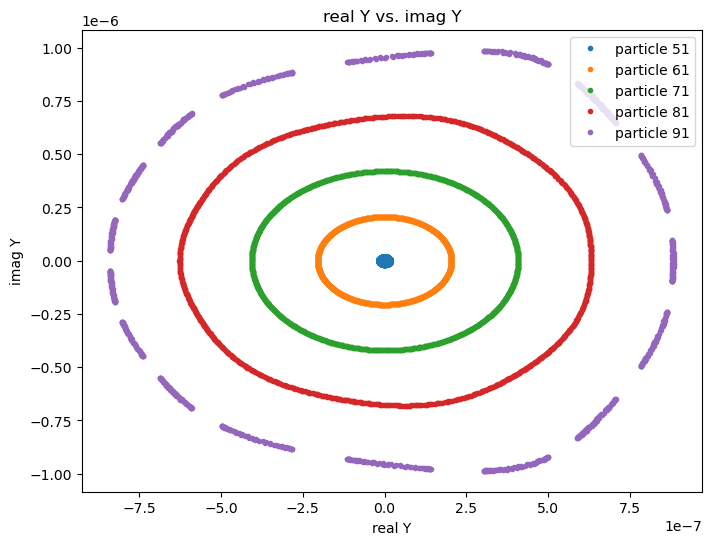

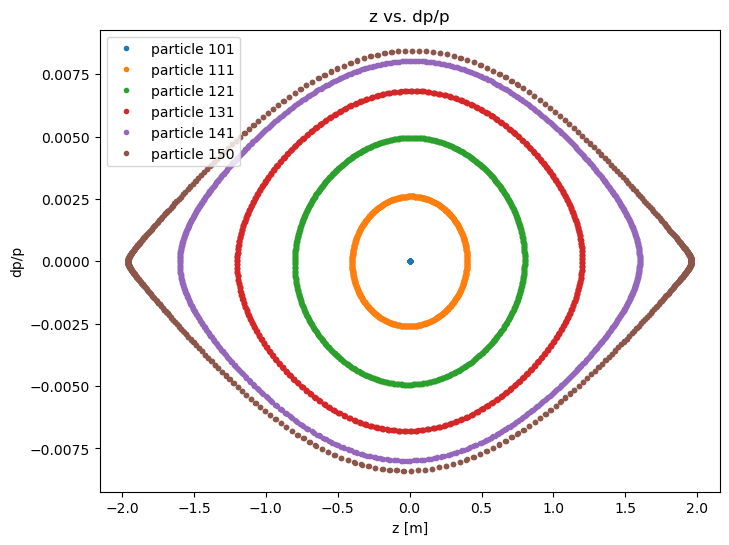

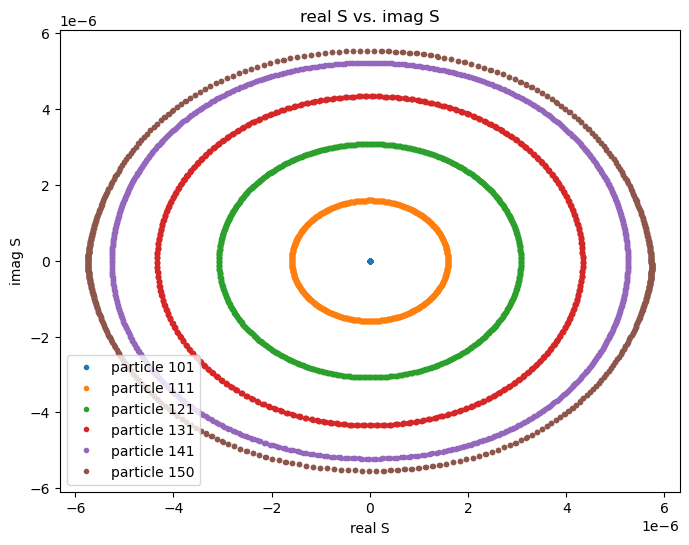

In [20]:
plot_traj('tracks.h5', 'nf.dat')

In [21]:
run(sxs=0.52)

Running with options
	volt: 0.2 (RF voltage [MV])
	qks: 0.0 (skew quadrupole)
	sxn: 0.0 (normal sextupole)
	sxs: 0.52 (skew sextupole)
	ocn: 0.0 (normal octupole)
	ocs: 0.0 (skew octupole)
000s, macroparticles = (143) / ()
Propagator: turn 954/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 955/inf., time = 0.001s, macroparticles = (143) / ()
Propagator: turn 956/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 957/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 958/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 959/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 960/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 961/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 962/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 963/inf., time = 0.000s, macroparticles = (143) / ()
Propagator: turn 964/inf., time = 0.000s, macroparticles = (143) / ()
Propaga

Propagator: turn 69/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 70/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 71/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 72/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 73/inf., time = 0.003s, macroparticles = (142) / ()
Propagator: turn 74/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 75/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 76/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 77/inf., time = 0.002s, macroparticles = (142) / ()
Propagator: turn 78/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 79/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 80/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 81/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 82/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 83/inf., time = 0

Propagator: turn 187/inf., time = 0.002s, macroparticles = (142) / ()
Propagator: turn 188/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 189/inf., time = 0.043s, macroparticles = (142) / ()
Propagator: turn 190/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 191/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 192/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 193/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 194/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 195/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 196/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 197/inf., time = 0.011s, macroparticles = (142) / ()
Propagator: turn 198/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 199/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 200/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 201

Propagator: turn 304/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 305/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 306/inf., time = 0.011s, macroparticles = (142) / ()
Propagator: turn 307/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 308/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 309/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 310/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 311/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 312/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 313/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 314/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 315/inf., time = 0.027s, macroparticles = (142) / ()
Propagator: turn 316/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 317/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 318

Propagator: turn 421/inf., time = 0.038s, macroparticles = (142) / ()
Propagator: turn 422/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 423/inf., time = 0.053s, macroparticles = (142) / ()
Propagator: turn 424/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 425/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 426/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 427/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 428/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 429/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 430/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 431/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 432/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 433/inf., time = 0.002s, macroparticles = (142) / ()
Propagator: turn 434/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 435

Propagator: turn 538/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 539/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 540/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 541/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 542/inf., time = 0.002s, macroparticles = (142) / ()
Propagator: turn 543/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 544/inf., time = 0.006s, macroparticles = (142) / ()
Propagator: turn 545/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 546/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 547/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 548/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 549/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 550/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 551/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 552

Propagator: turn 655/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 656/inf., time = 0.003s, macroparticles = (142) / ()
Propagator: turn 657/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 658/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 659/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 660/inf., time = 0.023s, macroparticles = (142) / ()
Propagator: turn 661/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 662/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 663/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 664/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 665/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 666/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 667/inf., time = 0.009s, macroparticles = (142) / ()
Propagator: turn 668/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 669

Propagator: turn 772/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 773/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 774/inf., time = 0.003s, macroparticles = (142) / ()
Propagator: turn 775/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 776/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 777/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 778/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 779/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 780/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 781/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 782/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 783/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 784/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 785/inf., time = 0.005s, macroparticles = (142) / ()
Propagator: turn 786

Propagator: turn 889/inf., time = 0.049s, macroparticles = (142) / ()
Propagator: turn 890/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 891/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 892/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 893/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 894/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 895/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 896/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 897/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 898/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 899/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 900/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 901/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 902/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 903

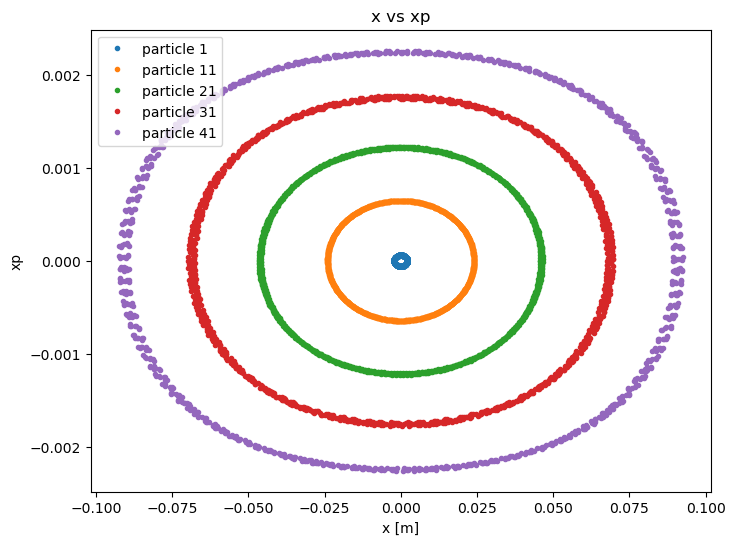

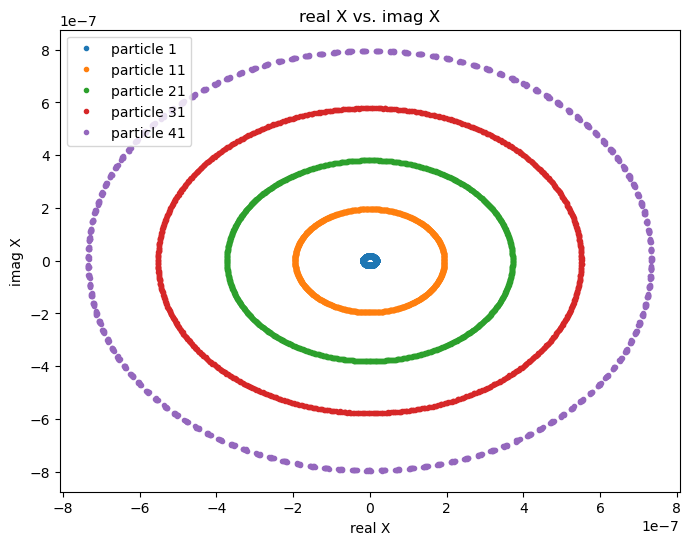

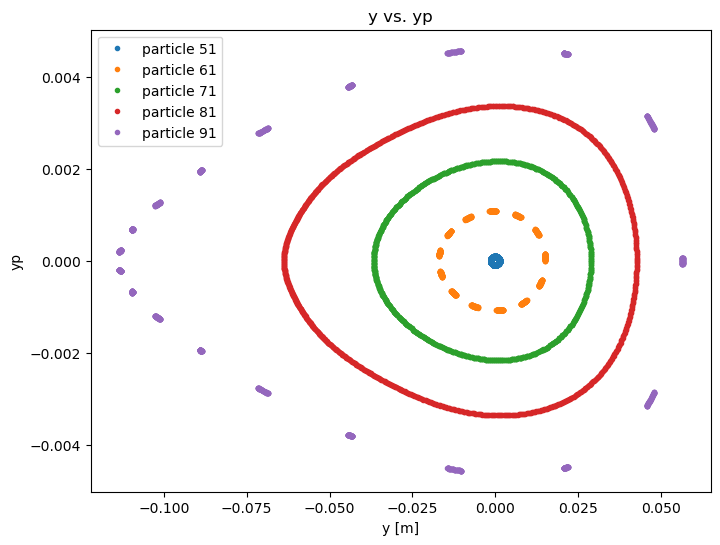

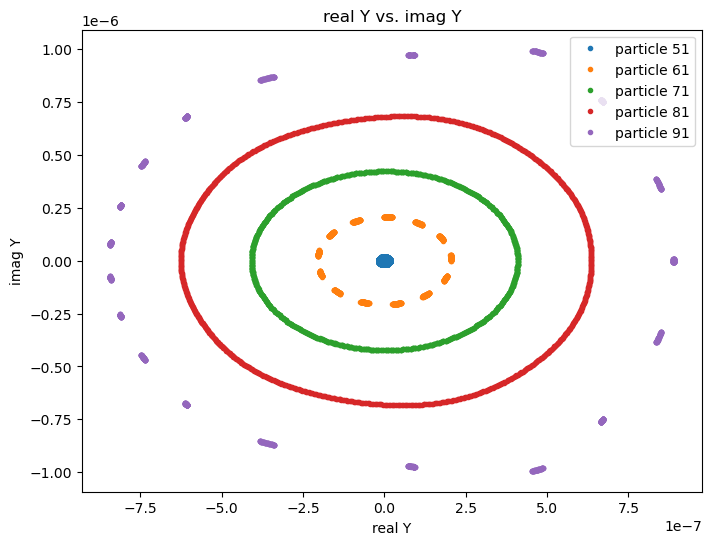

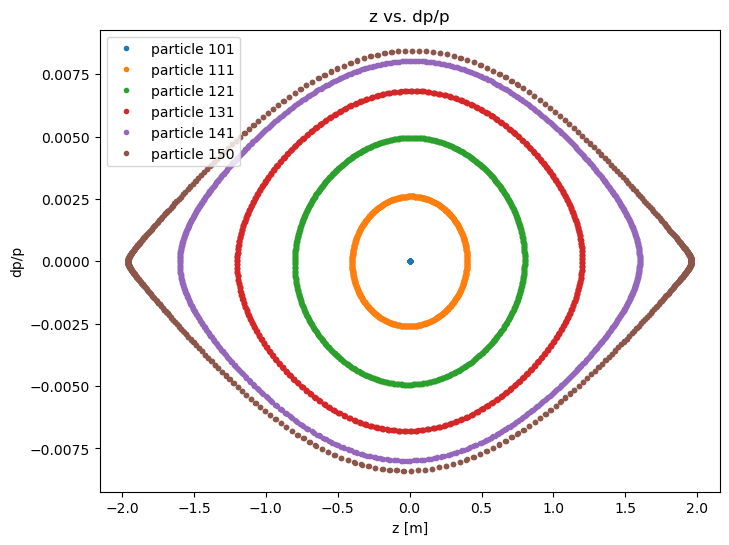

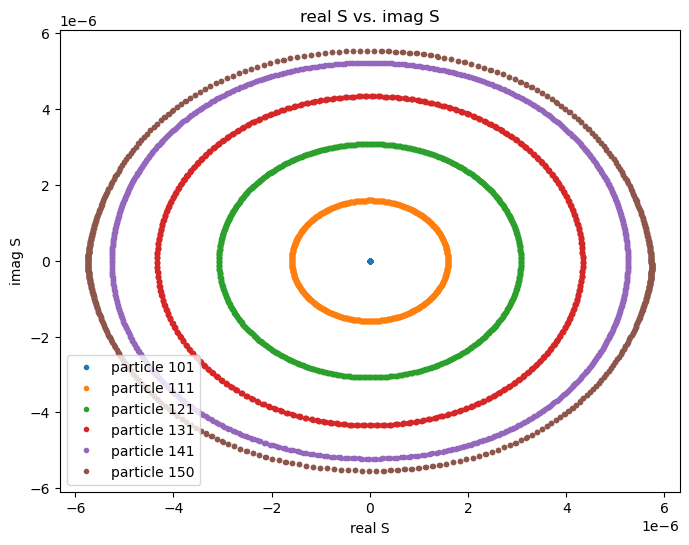

In [22]:
plot_traj('tracks.h5', 'nf.dat')

In [24]:
run(sxs=0.52, qks=0.001)

Running with options
	volt: 0.2 (RF voltage [MV])
	qks: 0.001 (skew quadrupole)
	sxn: 0.0 (normal sextupole)
	sxs: 0.52 (skew sextupole)
	ocn: 0.0 (normal octupole)
	ocs: 0.0 (skew octupole)
opagator: turn 948/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 949/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 950/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 951/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 952/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 953/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 954/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 955/inf., time = 0.043s, macroparticles = (142) / ()
Propagator: turn 956/inf., time = 0.089s, macroparticles = (142) / ()
Propagator: turn 957/inf., time = 0.057s, macroparticles = (142) / ()
Propagator: turn 958/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 959/inf., time = 0.002s,

Propagator: turn 64/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 65/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 66/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 67/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 68/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 69/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 70/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 71/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 72/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 73/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 74/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 75/inf., time = 0.002s, macroparticles = (142) / ()
Propagator: turn 76/inf., time = 0.003s, macroparticles = (142) / ()
Propagator: turn 77/inf., time = 0.014s, macroparticles = (142) / ()
Propagator: turn 78/inf., time = 0

Propagator: turn 181/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 182/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 183/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 184/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 185/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 186/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 187/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 188/inf., time = 0.003s, macroparticles = (142) / ()
Propagator: turn 189/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 190/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 191/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 192/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 193/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 194/inf., time = 0.002s, macroparticles = (142) / ()
Propagator: turn 195

Propagator: turn 298/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 299/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 300/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 301/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 302/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 303/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 304/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 305/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 306/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 307/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 308/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 309/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 310/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 311/inf., time = 0.006s, macroparticles = (142) / ()
Propagator: turn 312

Propagator: turn 415/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 416/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 417/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 418/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 419/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 420/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 421/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 422/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 423/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 424/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 425/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 426/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 427/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 428/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 429

Propagator: turn 532/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 533/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 534/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 535/inf., time = 0.002s, macroparticles = (142) / ()
Propagator: turn 536/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 537/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 538/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 539/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 540/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 541/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 542/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 543/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 544/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 545/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 546

Propagator: turn 649/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 650/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 651/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 652/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 653/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 654/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 655/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 656/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 657/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 658/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 659/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 660/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 661/inf., time = 0.007s, macroparticles = (142) / ()
Propagator: turn 662/inf., time = 0.034s, macroparticles = (142) / ()
Propagator: turn 663

Propagator: turn 767/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 768/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 769/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 770/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 771/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 772/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 773/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 774/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 775/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 776/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 777/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 778/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 779/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 780/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 781

Propagator: turn 942/inf., time = 0.00run finished0s, macroparticles = (142) / ()
Propagator: turn 943/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 944/inf., time = 0.001s, macroparticles = (142) / ()
Propagator: turn 945/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 946/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 947/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 948/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 949/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 950/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 951/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 952/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 953/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 954/inf., time = 0.000s, macroparticles = (142) / ()
Propagator: turn 955/inf., time = 0.002s, macroparticles = (142) / ()
Propagat

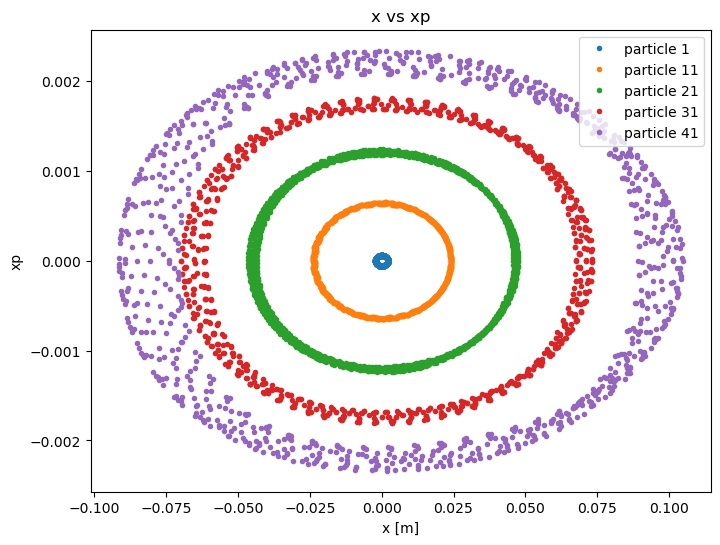

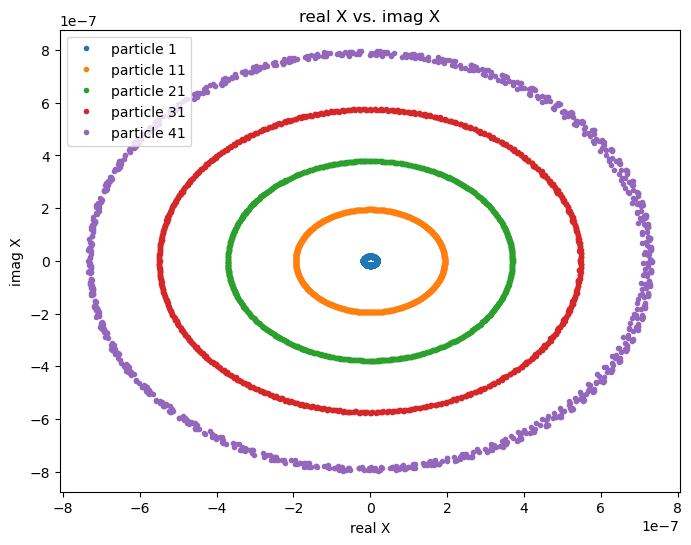

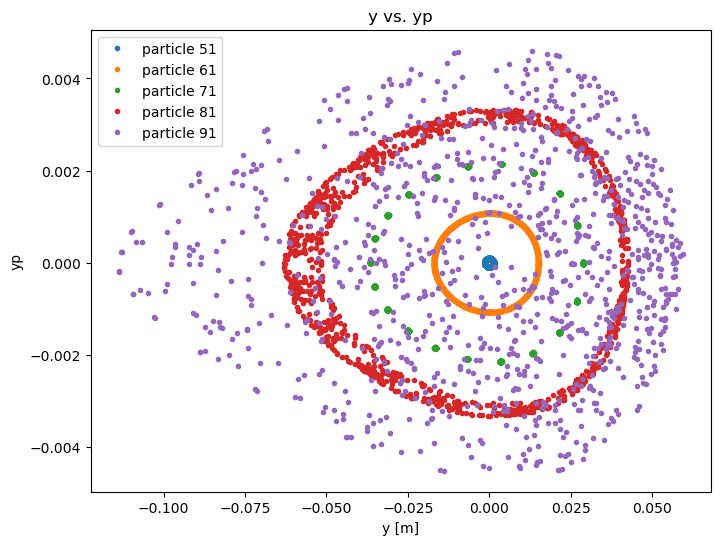

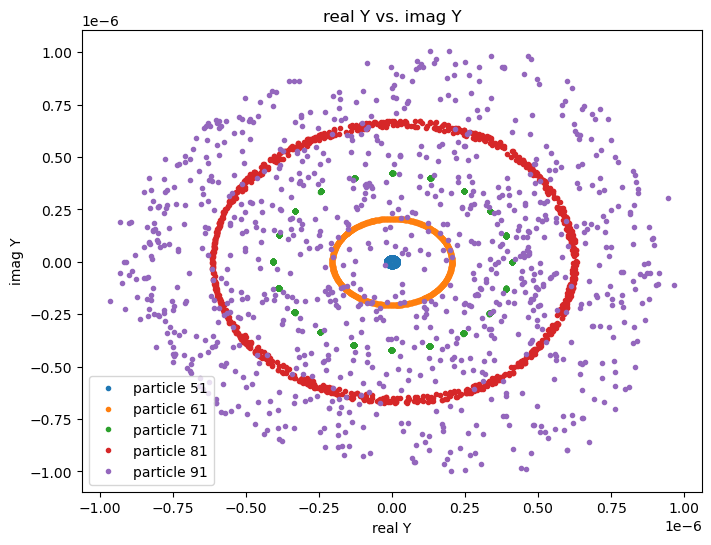

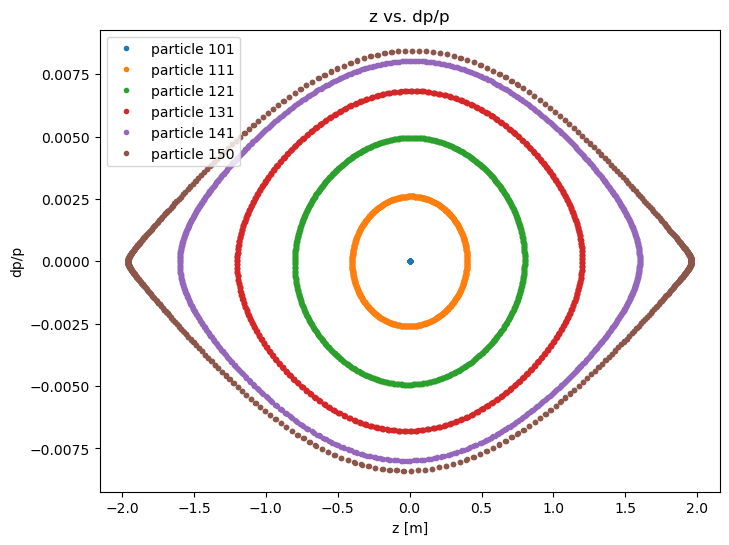

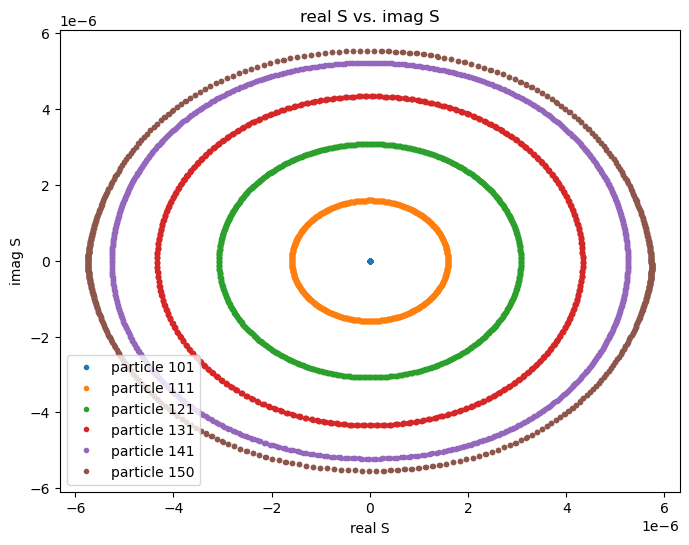

In [25]:
plot_traj('tracks.h5', 'nf.dat')